# Лабораторна робота №2
## Застосування методів кластеризації та зменшення розмірності

**Дисципліна:** Теорія та методи обчислювального інтелекту  
**Датасет:** Calories Burnt Prediction (Kaggle)  
**Посилання:** https://www.kaggle.com/datasets/ruchikakumbhar/calories-burnt-prediction

---

### Мета роботи
Ознайомитися з алгоритмами кластеризації K-Means та Fuzzy C-Means. Вивчити вплив зменшення розмірності даних за допомогою PCA на результати кластеризації. Порівняти отримані кластери за допомогою метрик (silhouette score тощо).

## 0. Імпорт бібліотек

In [ ]:
# Встановлення необхідних бібліотек (якщо відсутні)
# !pip install scikit-fuzzy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Препроцесинг
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Алгоритми кластеризації
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

# Метрики
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Fuzzy C-Means
import skfuzzy as fuzz

# Налаштування стилю графіків
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
RANDOM_STATE = 42

print('✅ Усі бібліотеки успішно імпортовано')

✅ Усі бібліотеки успішно імпортовано


---
## 1. Підготовка даних

### 1.1 Завантаження датасету

Датасет «Calories Burnt Prediction» — єдиний CSV-файл із такими колонками:

| Колонка | Тип | Опис |
|---------|-----|------|
| `User_ID` | int | Ідентифікатор користувача (видаляється перед кластеризацією) |
| `Gender` | str | Стать (`male` / `female`) → LabelEncoding |
| `Age` | float | Вік (років) |
| `Height` | float | Зріст (см) |
| `Weight` | float | Вага (кг) |
| `Duration` | float | Тривалість тренування (хв) |
| `Heart_Rate` | float | Середній пульс (уд/хв) |
| `Body_Temp` | float | Температура тіла (°C) |
| `Calories` | float | Витрачено калорій (цільова змінна) |

In [ ]:
# ─── Завантаження даних ───────────────────────────────────────────────────────
# Вкажіть шлях до файлу (за замовчуванням — та сама директорія)
CSV_PATH = 'calories.csv'

df = pd.read_csv(CSV_PATH)

# Очікувані колонки датасету
EXPECTED_COLS = ['User_ID', 'Gender', 'Age', 'Height', 'Weight',
                 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']
print('Наявні колонки:  ', df.columns.tolist())
print('Очікувані колонки:', EXPECTED_COLS)
print(f'\nРозмір датасету: {df.shape[0]:,} рядків × {df.shape[1]} стовпців')
df.head(10)

Наявні колонки:   ['User_ID', 'Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']
Очікувані колонки: ['User_ID', 'Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']

Розмір датасету: 15,000 рядків × 9 стовпців


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
5,15130815,female,36,151.0,50.0,23.0,96.0,40.7,123.0
6,19602372,female,33,158.0,56.0,22.0,95.0,40.5,112.0
7,11117088,male,41,175.0,85.0,25.0,100.0,40.7,143.0
8,12132339,male,60,186.0,94.0,21.0,97.0,40.4,134.0
9,17964668,female,26,146.0,51.0,16.0,90.0,40.2,72.0


In [ ]:
# Загальна інформація про датасет
print('=== Інформація про датасет ===')
df.info()
print('\n=== Статистика ===')
df.describe()

=== Інформація про датасет ===
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  str    
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), str(1)
memory usage: 1.0 MB

=== Статистика ===


,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


### 1.2 Попередня обробка даних

In [ ]:
# ─── Перевірка пропущених значень ────────────────────────────────────────────
print('=== Пропущені значення ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Кількість': missing, 'Відсоток (%)': missing_pct})
print(missing_df[missing_df['Кількість'] > 0])

if missing.sum() == 0:
    print('✅ Пропущених значень не виявлено')
else:
    # Заповнення числових пропусків медіаною
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    # Заповнення категоріальних пропусків модою
    cat_cols = df.select_dtypes(include=['object']).columns
    df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])
    print('✅ Пропущені значення заповнено (числові — медіаною, категоріальні — модою)')

=== Пропущені значення ===
Empty DataFrame
Columns: [Кількість, Відсоток (%)]
Index: []
✅ Пропущених значень не виявлено


In [ ]:
# ─── Кодування категоріальних змінних ────────────────────────────────────────
df_processed = df.copy()

# Видалення User_ID — не несе корисної інформації для кластеризації
if 'User_ID' in df_processed.columns:
    df_processed.drop(columns=['User_ID'], inplace=True)
    print('Видалено: User_ID')

# LabelEncoding для Gender: male->1, female->0
le = LabelEncoder()
df_processed['Gender'] = le.fit_transform(df_processed['Gender'])
print(f'Gender закодовано: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print(f'\nФінальні ознаки ({df_processed.shape[1]}): {df_processed.columns.tolist()}')
df_processed.describe().round(2)

Видалено: User_ID
Gender закодовано: {'female': np.int64(0), 'male': np.int64(1)}

Фінальні ознаки (8): ['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.0,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,0.5,42.79,174.47,74.97,15.53,95.52,40.03,89.54
std,0.5,16.98,14.26,15.04,8.32,9.58,0.78,62.46
min,0.0,20.00,123.00,36.00,1.00,67.00,37.10,1.00
25%,0.0,28.00,164.00,63.00,8.00,88.00,39.60,35.00
50%,0.0,39.00,175.00,74.00,16.00,96.00,40.20,79.00
75%,1.0,56.00,185.00,87.00,23.00,103.00,40.60,138.00
max,1.0,79.00,222.00,132.00,30.00,128.00,41.50,314.00


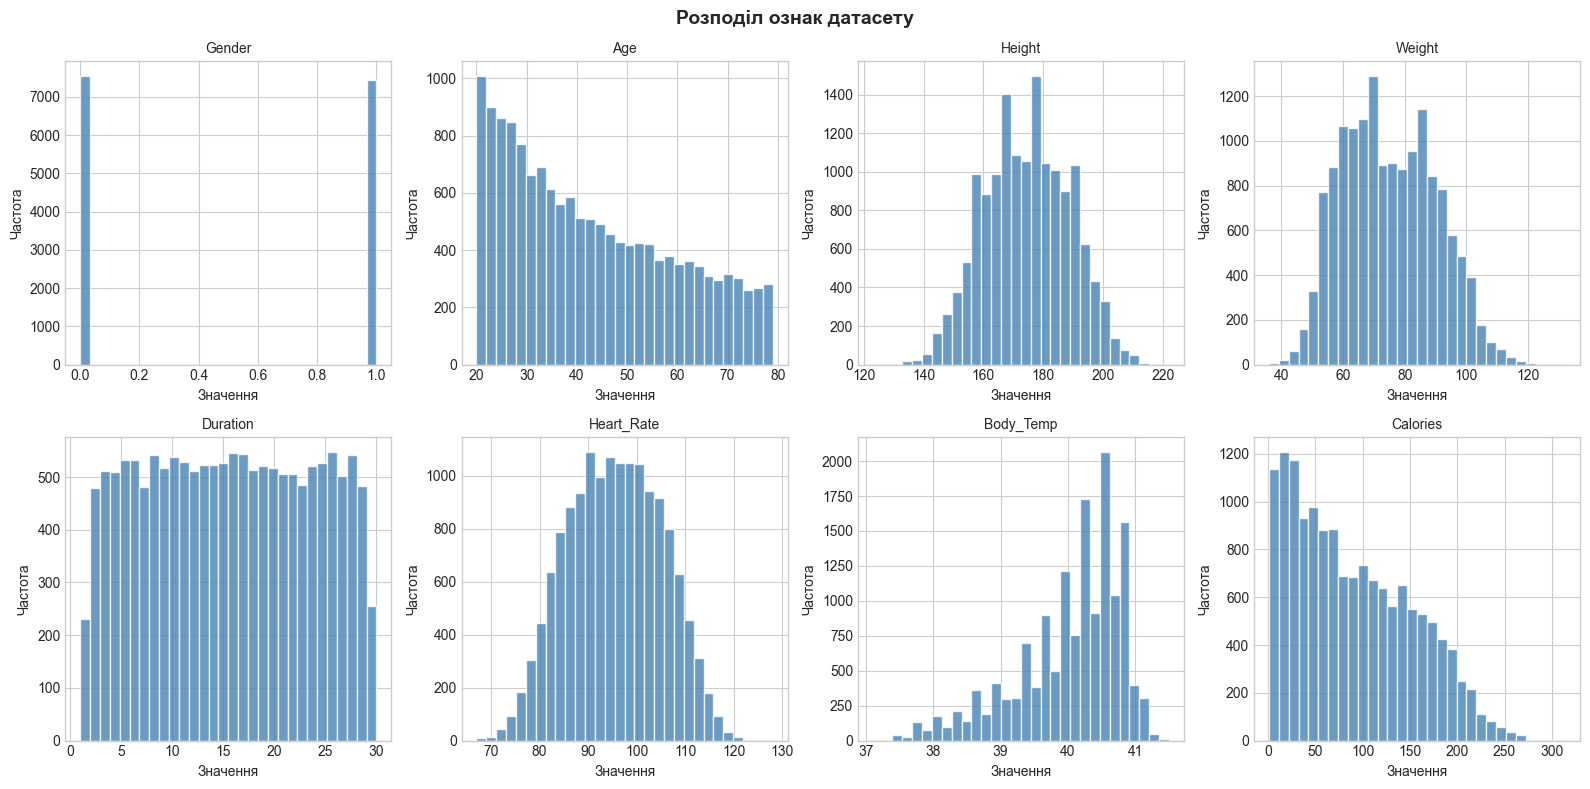

In [ ]:
# ─── Візуалізація розподілу ознак ─────────────────────────────────────────────
fig, axes = plt.subplots(2, (df_processed.shape[1] + 1) // 2, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(df_processed.columns):
    axes[i].hist(df_processed[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Значення')
    axes[i].set_ylabel('Частота')

# Сховати зайві осі
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Розподіл ознак датасету', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ─── Масштабування даних (StandardScaler) ─────────────────────────────────────
# StandardScaler обрано через нормальний розподіл більшості ознак та
# чутливість алгоритмів (K-Means, DBSCAN) до масштабу даних
X = df_processed.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('✅ Дані стандартизовано (StandardScaler)')
print(f'   Середнє (перші 3 ознаки): {X_scaled.mean(axis=0)[:3].round(4)}')
print(f'   СКВ   (перші 3 ознаки): {X_scaled.std(axis=0)[:3].round(4)}')

✅ Дані стандартизовано (StandardScaler)
   Середнє (перші 3 ознаки): [ 0.  0. -0.]
   СКВ   (перші 3 ознаки): [1. 1. 1.]


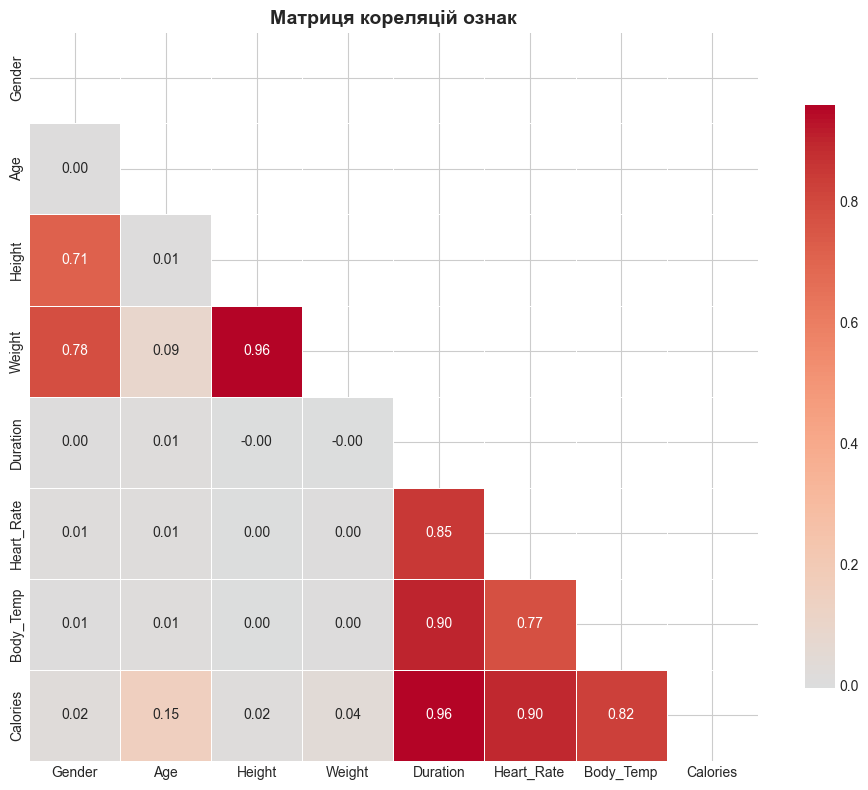

In [ ]:
# ─── Матриця кореляцій ────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
corr_matrix = df_processed.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Матриця кореляцій ознак', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

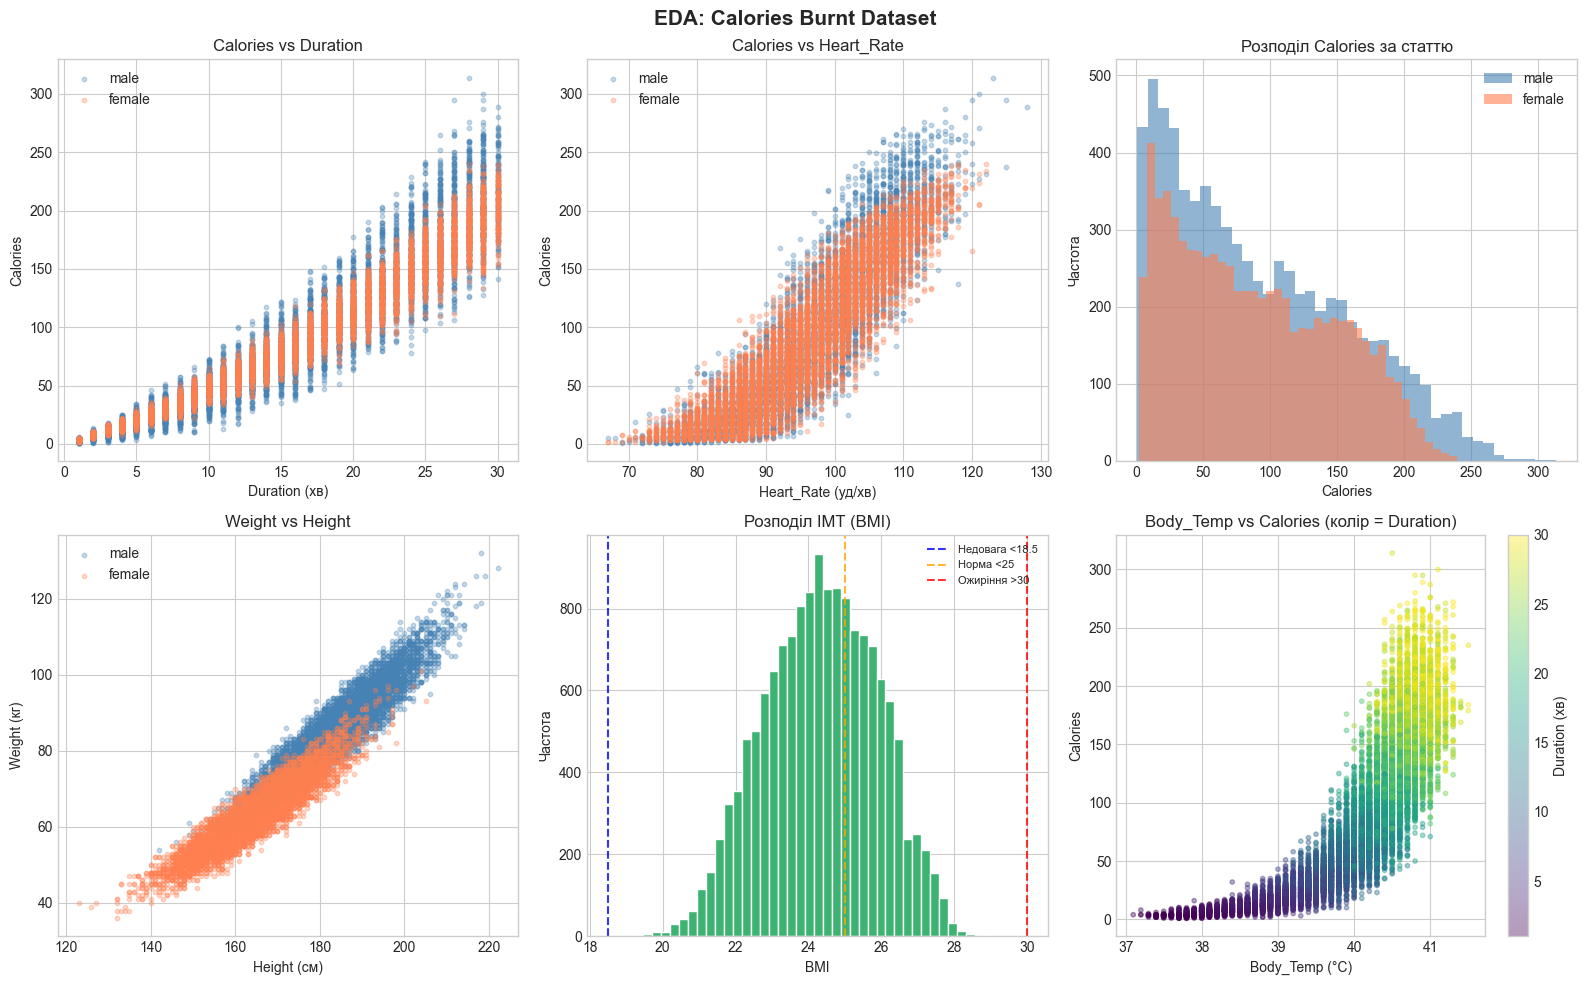

In [ ]:
# ─── EDA: Аналіз ключових залежностей датасету ───────────────────────────────
df_eda = df.copy()
df_eda['BMI'] = df_eda['Weight'] / (df_eda['Height'] / 100) ** 2

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Calories vs Duration
for gender, color in [('male', 'steelblue'), ('female', 'coral')]:
    mask = df_eda['Gender'] == gender
    axes[0, 0].scatter(df_eda[mask]['Duration'], df_eda[mask]['Calories'],
                       alpha=0.3, s=10, color=color, label=gender)
axes[0, 0].set_xlabel('Duration (хв)'); axes[0, 0].set_ylabel('Calories')
axes[0, 0].set_title('Calories vs Duration'); axes[0, 0].legend()

# 2. Calories vs Heart_Rate
for gender, color in [('male', 'steelblue'), ('female', 'coral')]:
    mask = df_eda['Gender'] == gender
    axes[0, 1].scatter(df_eda[mask]['Heart_Rate'], df_eda[mask]['Calories'],
                       alpha=0.3, s=10, color=color, label=gender)
axes[0, 1].set_xlabel('Heart_Rate (уд/хв)'); axes[0, 1].set_ylabel('Calories')
axes[0, 1].set_title('Calories vs Heart_Rate'); axes[0, 1].legend()

# 3. Розподіл Calories за статтю
axes[0, 2].hist(df_eda[df_eda['Gender'] == 'male']['Calories'],
                bins=40, alpha=0.6, color='steelblue', label='male')
axes[0, 2].hist(df_eda[df_eda['Gender'] == 'female']['Calories'],
                bins=40, alpha=0.6, color='coral', label='female')
axes[0, 2].set_xlabel('Calories'); axes[0, 2].set_ylabel('Частота')
axes[0, 2].set_title('Розподіл Calories за статтю'); axes[0, 2].legend()

# 4. Weight vs Height
for gender, color in [('male', 'steelblue'), ('female', 'coral')]:
    mask = df_eda['Gender'] == gender
    axes[1, 0].scatter(df_eda[mask]['Height'], df_eda[mask]['Weight'],
                       alpha=0.3, s=10, color=color, label=gender)
axes[1, 0].set_xlabel('Height (см)'); axes[1, 0].set_ylabel('Weight (кг)')
axes[1, 0].set_title('Weight vs Height'); axes[1, 0].legend()

# 5. BMI розподіл
axes[1, 1].hist(df_eda['BMI'], bins=40, color='mediumseagreen', edgecolor='white')
for val, color, lbl in [(18.5, 'blue', 'Недовага <18.5'),
                         (25.0, 'orange', 'Норма <25'),
                         (30.0, 'red', 'Ожиріння >30')]:
    axes[1, 1].axvline(val, color=color, linestyle='--', alpha=0.8, label=lbl)
axes[1, 1].set_xlabel('BMI'); axes[1, 1].set_ylabel('Частота')
axes[1, 1].set_title('Розподіл ІМТ (BMI)'); axes[1, 1].legend(fontsize=8)

# 6. Body_Temp vs Calories (колір = Duration)
sc = axes[1, 2].scatter(df_eda['Body_Temp'], df_eda['Calories'],
                         c=df_eda['Duration'], cmap='viridis', alpha=0.4, s=10)
plt.colorbar(sc, ax=axes[1, 2], label='Duration (хв)')
axes[1, 2].set_xlabel('Body_Temp (°C)'); axes[1, 2].set_ylabel('Calories')
axes[1, 2].set_title('Body_Temp vs Calories (колір = Duration)')

plt.suptitle('EDA: Calories Burnt Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Визначення оптимальної кількості кластерів

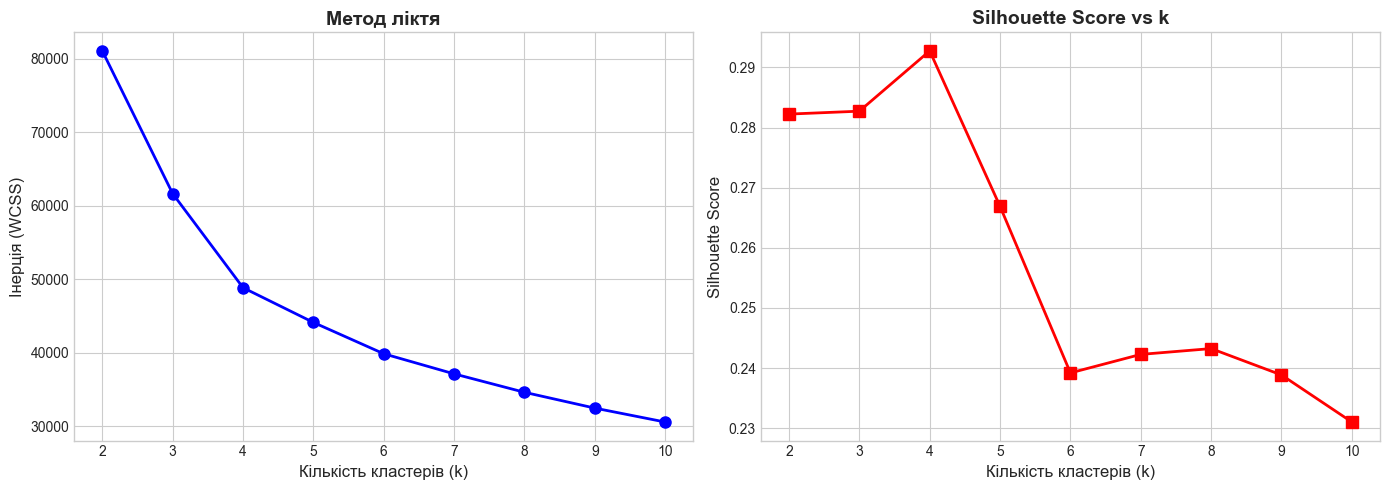


📌 Оптимальна кількість кластерів за Silhouette: k = 4


In [ ]:
# ─── Метод ліктя (Elbow Method) ───────────────────────────────────────────────
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', markersize=8, linewidth=2)
axes[0].set_xlabel('Кількість кластерів (k)', fontsize=12)
axes[0].set_ylabel('Інерція (WCSS)', fontsize=12)
axes[0].set_title('Метод ліктя', fontsize=14, fontweight='bold')
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, silhouette_scores, 'rs-', markersize=8, linewidth=2)
axes[1].set_xlabel('Кількість кластерів (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs k', fontsize=14, fontweight='bold')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(silhouette_scores)]
print(f'\n📌 Оптимальна кількість кластерів за Silhouette: k = {best_k}')

In [ ]:
# Встановлення кількості кластерів
N_CLUSTERS = best_k
print(f'Використовується N_CLUSTERS = {N_CLUSTERS}')

Використовується N_CLUSTERS = 4


---
## 3. Кластеризація у вихідному просторі (без PCA)

### 3.1 K-Means

In [ ]:
# ─── K-Means ──────────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
db_kmeans  = davies_bouldin_score(X_scaled, labels_kmeans)
ch_kmeans  = calinski_harabasz_score(X_scaled, labels_kmeans)

print('=== K-Means (без PCA) ===')
print(f'  Silhouette Score:            {sil_kmeans:.4f}')
print(f'  Davies-Bouldin Index:        {db_kmeans:.4f}  (менше — краще)')
print(f'  Calinski-Harabasz Index:     {ch_kmeans:.2f}  (більше — краще)')

unique, counts = np.unique(labels_kmeans, return_counts=True)
print(f'\n  Розподіл за кластерами: { dict(zip(unique, counts)) }')

=== K-Means (без PCA) ===
  Silhouette Score:            0.2927
  Davies-Bouldin Index:        1.1726  (менше — краще)
  Calinski-Harabasz Index:     7278.49  (більше — краще)

  Розподіл за кластерами: {np.int32(0): np.int64(3592), np.int32(1): np.int64(3668), np.int32(2): np.int64(3996), np.int32(3): np.int64(3744)}


### 3.2 Fuzzy C-Means

In [ ]:
# ─── Fuzzy C-Means ────────────────────────────────────────────────────────────
# skfuzzy очікує транспоновану матрицю (ознаки — рядки)
X_t = X_scaled.T

m       = 2.0    # показник нечіткості
error   = 0.005
maxiter = 1000

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_t, c=N_CLUSTERS, m=m,
    error=error, maxiter=maxiter,
    init=None, seed=RANDOM_STATE
)

# «Жорстке» розбиття — кластер з максимальним ступенем приналежності
labels_fcm = np.argmax(u, axis=0)

sil_fcm = silhouette_score(X_scaled, labels_fcm)
db_fcm  = davies_bouldin_score(X_scaled, labels_fcm)
ch_fcm  = calinski_harabasz_score(X_scaled, labels_fcm)

# Fuzzy Partition Coefficient
fpc_val = fpc

print('=== Fuzzy C-Means (без PCA) ===')
print(f'  Silhouette Score:            {sil_fcm:.4f}')
print(f'  Davies-Bouldin Index:        {db_fcm:.4f}')
print(f'  Calinski-Harabasz Index:     {ch_fcm:.2f}')
print(f'  Fuzzy Partition Coefficient: {fpc_val:.4f}  (ближче до 1 — краще)')

unique, counts = np.unique(labels_fcm, return_counts=True)
print(f'\n  Розподіл за кластерами: { dict(zip(unique, counts)) }')

=== Fuzzy C-Means (без PCA) ===
  Silhouette Score:            0.2922
  Davies-Bouldin Index:        1.1734
  Calinski-Harabasz Index:     7274.91
  Fuzzy Partition Coefficient: 0.4365  (ближче до 1 — краще)

  Розподіл за кластерами: {np.int64(0): np.int64(3929), np.int64(1): np.int64(3680), np.int64(2): np.int64(3744), np.int64(3): np.int64(3647)}


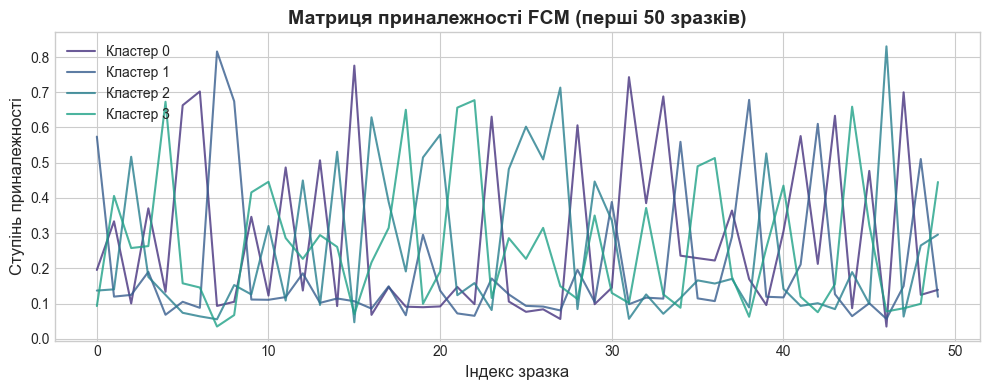

In [ ]:
# Візуалізація матриці приналежності FCM (перші 20 зразків)
plt.figure(figsize=(10, 4))
for i in range(N_CLUSTERS):
    plt.plot(u[i, :50], label=f'Кластер {i}', alpha=0.8)
plt.xlabel('Індекс зразка', fontsize=12)
plt.ylabel('Ступінь приналежності', fontsize=12)
plt.title('Матриця приналежності FCM (перші 50 зразків)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 3.3 Gaussian Mixture Model (GMM)

=== Gaussian Mixture Model (без PCA) ===
  Silhouette Score:        0.2859
  Davies-Bouldin Index:    1.1895
  Calinski-Harabasz Index: 7027.91
  BIC (поточна модель):    -57786.72


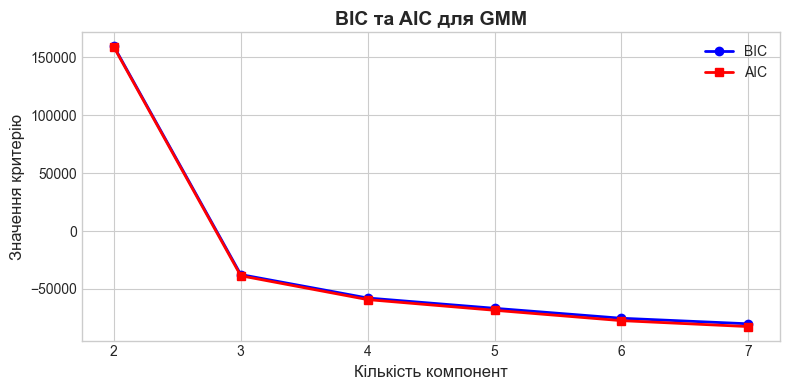

In [ ]:
# ─── GMM ──────────────────────────────────────────────────────────────────────
gmm = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE)
gmm.fit(X_scaled)
labels_gmm = gmm.predict(X_scaled)
proba_gmm  = gmm.predict_proba(X_scaled)

sil_gmm = silhouette_score(X_scaled, labels_gmm)
db_gmm  = davies_bouldin_score(X_scaled, labels_gmm)
ch_gmm  = calinski_harabasz_score(X_scaled, labels_gmm)

# BIC / AIC для вибору кількості компонент
bic_scores = [GaussianMixture(n_components=k, random_state=RANDOM_STATE).fit(X_scaled).bic(X_scaled)
              for k in range(2, 8)]
aic_scores = [GaussianMixture(n_components=k, random_state=RANDOM_STATE).fit(X_scaled).aic(X_scaled)
              for k in range(2, 8)]

print('=== Gaussian Mixture Model (без PCA) ===')
print(f'  Silhouette Score:        {sil_gmm:.4f}')
print(f'  Davies-Bouldin Index:    {db_gmm:.4f}')
print(f'  Calinski-Harabasz Index: {ch_gmm:.2f}')
print(f'  BIC (поточна модель):    {gmm.bic(X_scaled):.2f}')

# BIC/AIC графік
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(2, 8), bic_scores, 'bo-', label='BIC', linewidth=2)
ax.plot(range(2, 8), aic_scores, 'rs-', label='AIC', linewidth=2)
ax.set_xlabel('Кількість компонент', fontsize=12)
ax.set_ylabel('Значення критерію', fontsize=12)
ax.set_title('BIC та AIC для GMM', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 3.4 DBSCAN

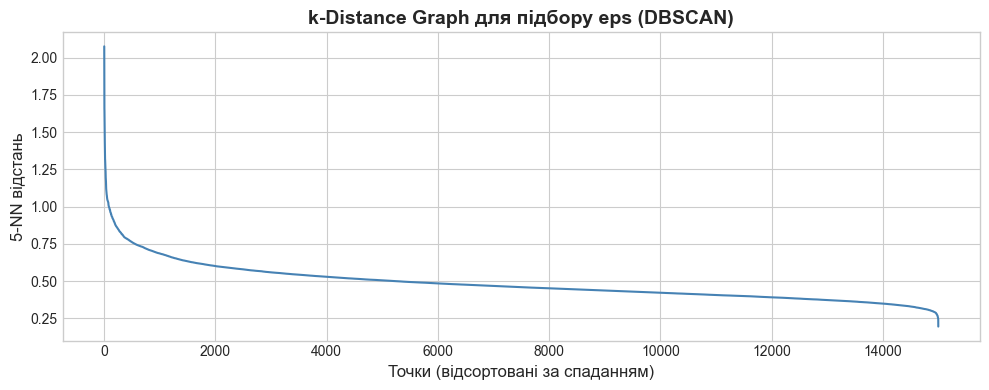

In [ ]:
# ─── Підбір eps за k-відстанями ───────────────────────────────────────────────
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
distances_sorted = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(distances_sorted, linewidth=1.5, color='steelblue')
plt.xlabel('Точки (відсортовані за спаданням)', fontsize=12)
plt.ylabel('5-NN відстань', fontsize=12)
plt.title('k-Distance Graph для підбору eps (DBSCAN)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ─── DBSCAN ───────────────────────────────────────────────────────────────────
# Параметри підбираються на основі k-distance графіку
EPS       = 0.8   # ← скоригуйте за графіком вище
MIN_SAMP  = 10

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMP)
labels_dbscan = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise       = np.sum(labels_dbscan == -1)

print(f'DBSCAN: eps={EPS}, min_samples={MIN_SAMP}')
print(f'  Знайдено кластерів: {n_clusters_db}')
print(f'  Шумових точок:      {n_noise} ({n_noise/len(labels_dbscan)*100:.1f}%)')

# Silhouette для DBSCAN (лише «справжні» кластери)
mask_db = labels_dbscan != -1
if n_clusters_db >= 2 and mask_db.sum() > 10:
    sil_dbscan = silhouette_score(X_scaled[mask_db], labels_dbscan[mask_db])
    db_dbscan  = davies_bouldin_score(X_scaled[mask_db], labels_dbscan[mask_db])
    print(f'\n  Silhouette Score (без шуму): {sil_dbscan:.4f}')
    print(f'  Davies-Bouldin Index:        {db_dbscan:.4f}')
else:
    sil_dbscan = np.nan
    db_dbscan  = np.nan
    print('  ⚠️  Недостатньо кластерів для розрахунку Silhouette')

DBSCAN: eps=0.8, min_samples=10
  Знайдено кластерів: 2
  Шумових точок:      212 (1.4%)

  Silhouette Score (без шуму): 0.2741
  Davies-Bouldin Index:        1.5475


---
## 4. Зменшення розмірності за допомогою PCA

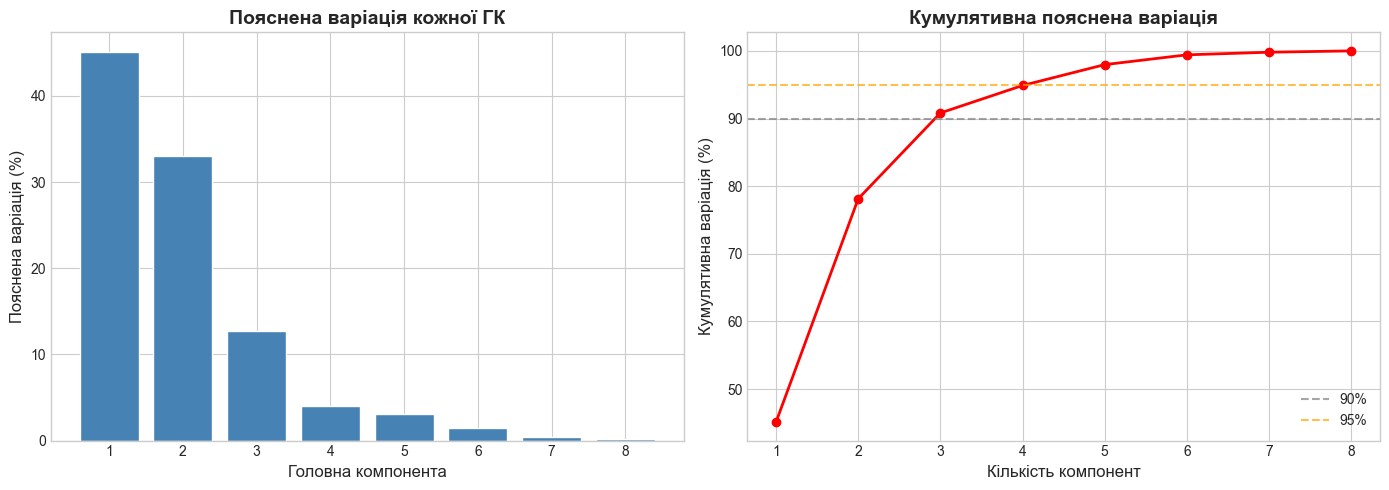

ГК  1: 45.12%  | Кумулятивно:  45.12%
ГК  2: 33.01%  | Кумулятивно:  78.14%
ГК  3: 12.68%  | Кумулятивно:  90.82%
ГК  4:  4.06%  | Кумулятивно:  94.88%
ГК  5:  3.09%  | Кумулятивно:  97.97%
ГК  6:  1.45%  | Кумулятивно:  99.42%
ГК  7:  0.39%  | Кумулятивно:  99.80%
ГК  8:  0.20%  | Кумулятивно: 100.00%


In [ ]:
# ─── Аналіз поясненої варіації ────────────────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Індивідуальна пояснена варіація
axes[0].bar(range(1, len(explained) + 1), explained * 100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Головна компонента', fontsize=12)
axes[0].set_ylabel('Пояснена варіація (%)', fontsize=12)
axes[0].set_title('Пояснена варіація кожної ГК', fontsize=14, fontweight='bold')

# Кумулятивна пояснена варіація
axes[1].plot(range(1, len(cumulative) + 1), cumulative * 100, 'ro-', linewidth=2)
axes[1].axhline(y=90, color='gray', linestyle='--', alpha=0.7, label='90%')
axes[1].axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='95%')
axes[1].set_xlabel('Кількість компонент', fontsize=12)
axes[1].set_ylabel('Кумулятивна варіація (%)', fontsize=12)
axes[1].set_title('Кумулятивна пояснена варіація', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

for i, (ev, cum) in enumerate(zip(explained, cumulative), 1):
    print(f'ГК {i:2d}: {ev*100:5.2f}%  | Кумулятивно: {cum*100:6.2f}%')

### 4.1 PCA до 2 компонент

In [ ]:
# ─── PCA: 2 компоненти ────────────────────────────────────────────────────────
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_scaled)

var2 = pca2.explained_variance_ratio_.sum() * 100
print(f'PCA (2 ГК): пояснена варіація = {var2:.2f}%')
print(f'  ГК1: {pca2.explained_variance_ratio_[0]*100:.2f}%')
print(f'  ГК2: {pca2.explained_variance_ratio_[1]*100:.2f}%')

PCA (2 ГК): пояснена варіація = 78.14%
  ГК1: 45.12%
  ГК2: 33.01%


In [ ]:
# ─── Кластеризація після PCA (2 компоненти) ───────────────────────────────────
results = {}

# K-Means
km2 = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
lbl_km2 = km2.fit_predict(X_pca2)
results['KMeans_PCA2'] = {
    'labels': lbl_km2,
    'sil': silhouette_score(X_pca2, lbl_km2),
    'db':  davies_bouldin_score(X_pca2, lbl_km2),
    'ch':  calinski_harabasz_score(X_pca2, lbl_km2)
}

# Fuzzy C-Means
cntr2, u2, _, _, _, _, fpc2 = fuzz.cluster.cmeans(
    X_pca2.T, c=N_CLUSTERS, m=2.0, error=0.005, maxiter=1000, seed=RANDOM_STATE)
lbl_fcm2 = np.argmax(u2, axis=0)
results['FCM_PCA2'] = {
    'labels': lbl_fcm2,
    'sil': silhouette_score(X_pca2, lbl_fcm2),
    'db':  davies_bouldin_score(X_pca2, lbl_fcm2),
    'ch':  calinski_harabasz_score(X_pca2, lbl_fcm2),
    'fpc': fpc2
}

# GMM
gmm2 = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE)
lbl_gmm2 = gmm2.fit_predict(X_pca2)
results['GMM_PCA2'] = {
    'labels': lbl_gmm2,
    'sil': silhouette_score(X_pca2, lbl_gmm2),
    'db':  davies_bouldin_score(X_pca2, lbl_gmm2),
    'ch':  calinski_harabasz_score(X_pca2, lbl_gmm2)
}

# DBSCAN
db2 = DBSCAN(eps=0.5, min_samples=10).fit_predict(X_pca2)
n_cl_db2 = len(set(db2)) - (1 if -1 in db2 else 0)
mask_db2 = db2 != -1
sil_db2 = silhouette_score(X_pca2[mask_db2], db2[mask_db2]) if n_cl_db2 >= 2 else np.nan
results['DBSCAN_PCA2'] = {'labels': db2, 'sil': sil_db2, 'n_clusters': n_cl_db2}

for name, res in results.items():
    print(f'{name:15s}  Silhouette={res["sil"]:.4f}', end='')
    if 'db' in res:  print(f'  DB={res["db"]:.4f}  CH={res["ch"]:.1f}', end='')
    print()

KMeans_PCA2      Silhouette=0.4239  DB=0.7836  CH=15113.3
FCM_PCA2         Silhouette=0.4240  DB=0.7835  CH=15112.7
GMM_PCA2         Silhouette=0.4236  DB=0.7833  CH=15083.5
DBSCAN_PCA2      Silhouette=nan


### 4.2 PCA до 4-5 компонент

In [ ]:
# ─── PCA: 4 або 5 компонент ───────────────────────────────────────────────────
N_COMP45 = min(5, X_scaled.shape[1])  # не більше ніж кількість ознак

pca45 = PCA(n_components=N_COMP45, random_state=RANDOM_STATE)
X_pca45 = pca45.fit_transform(X_scaled)

var45 = pca45.explained_variance_ratio_.sum() * 100
print(f'PCA ({N_COMP45} ГК): пояснена варіація = {var45:.2f}%')
for i, ev in enumerate(pca45.explained_variance_ratio_, 1):
    print(f'  ГК{i}: {ev*100:.2f}%')

PCA (5 ГК): пояснена варіація = 97.97%
  ГК1: 45.12%
  ГК2: 33.01%
  ГК3: 12.68%
  ГК4: 4.06%
  ГК5: 3.09%


In [ ]:
# ─── Кластеризація після PCA (4-5 компонент) ──────────────────────────────────

# K-Means
km45 = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
lbl_km45 = km45.fit_predict(X_pca45)
results['KMeans_PCA45'] = {
    'labels': lbl_km45,
    'sil': silhouette_score(X_pca45, lbl_km45),
    'db':  davies_bouldin_score(X_pca45, lbl_km45),
    'ch':  calinski_harabasz_score(X_pca45, lbl_km45)
}

# Fuzzy C-Means
cntr45, u45, _, _, _, _, fpc45 = fuzz.cluster.cmeans(
    X_pca45.T, c=N_CLUSTERS, m=2.0, error=0.005, maxiter=1000, seed=RANDOM_STATE)
lbl_fcm45 = np.argmax(u45, axis=0)
results['FCM_PCA45'] = {
    'labels': lbl_fcm45,
    'sil': silhouette_score(X_pca45, lbl_fcm45),
    'db':  davies_bouldin_score(X_pca45, lbl_fcm45),
    'ch':  calinski_harabasz_score(X_pca45, lbl_fcm45),
    'fpc': fpc45
}

# GMM
gmm45 = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE)
lbl_gmm45 = gmm45.fit_predict(X_pca45)
results['GMM_PCA45'] = {
    'labels': lbl_gmm45,
    'sil': silhouette_score(X_pca45, lbl_gmm45),
    'db':  davies_bouldin_score(X_pca45, lbl_gmm45),
    'ch':  calinski_harabasz_score(X_pca45, lbl_gmm45)
}

# DBSCAN
db45 = DBSCAN(eps=0.8, min_samples=10).fit_predict(X_pca45)
n_cl_db45 = len(set(db45)) - (1 if -1 in db45 else 0)
mask_db45 = db45 != -1
sil_db45 = silhouette_score(X_pca45[mask_db45], db45[mask_db45]) if n_cl_db45 >= 2 else np.nan
results['DBSCAN_PCA45'] = {'labels': db45, 'sil': sil_db45, 'n_clusters': n_cl_db45}

for name, res in results.items():
    print(f'{name:15s}  Silhouette={res["sil"]:.4f}', end='')
    if 'db' in res: print(f'  DB={res["db"]:.4f}  CH={res["ch"]:.1f}', end='')
    print()

KMeans_PCA2      Silhouette=0.4239  DB=0.7836  CH=15113.3
FCM_PCA2         Silhouette=0.4240  DB=0.7835  CH=15112.7
GMM_PCA2         Silhouette=0.4236  DB=0.7833  CH=15083.5
DBSCAN_PCA2      Silhouette=nan
KMeans_PCA45     Silhouette=0.3025  DB=1.1408  CH=7649.2
FCM_PCA45        Silhouette=0.3020  DB=1.1415  CH=7645.9
GMM_PCA45        Silhouette=0.2967  DB=1.1562  CH=7405.0
DBSCAN_PCA45     Silhouette=0.2792


---
## 5. Візуалізація результатів

In [ ]:
# ─── Допоміжна функція візуалізації ──────────────────────────────────────────
def plot_clusters_2d(X2d, labels, title, centroids=None, ax=None):
    """Побудова 2D scatter-plot кластерів."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    
    unique_labels = sorted(set(labels))
    palette = plt.cm.get_cmap('tab10', len(unique_labels))
    
    for i, lbl in enumerate(unique_labels):
        mask = labels == lbl
        color = 'gray' if lbl == -1 else palette(i)
        label = 'Шум' if lbl == -1 else f'Кластер {lbl}'
        ax.scatter(X2d[mask, 0], X2d[mask, 1],
                   c=[color], label=label, alpha=0.6, s=20, edgecolors='none')
    
    if centroids is not None:
        ax.scatter(centroids[:, 0], centroids[:, 1],
                   c='red', marker='*', s=200, zorder=10, label='Центроїди')
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('ГК 1', fontsize=10)
    ax.set_ylabel('ГК 2', fontsize=10)
    ax.legend(fontsize=8, markerscale=1.5)
    return ax

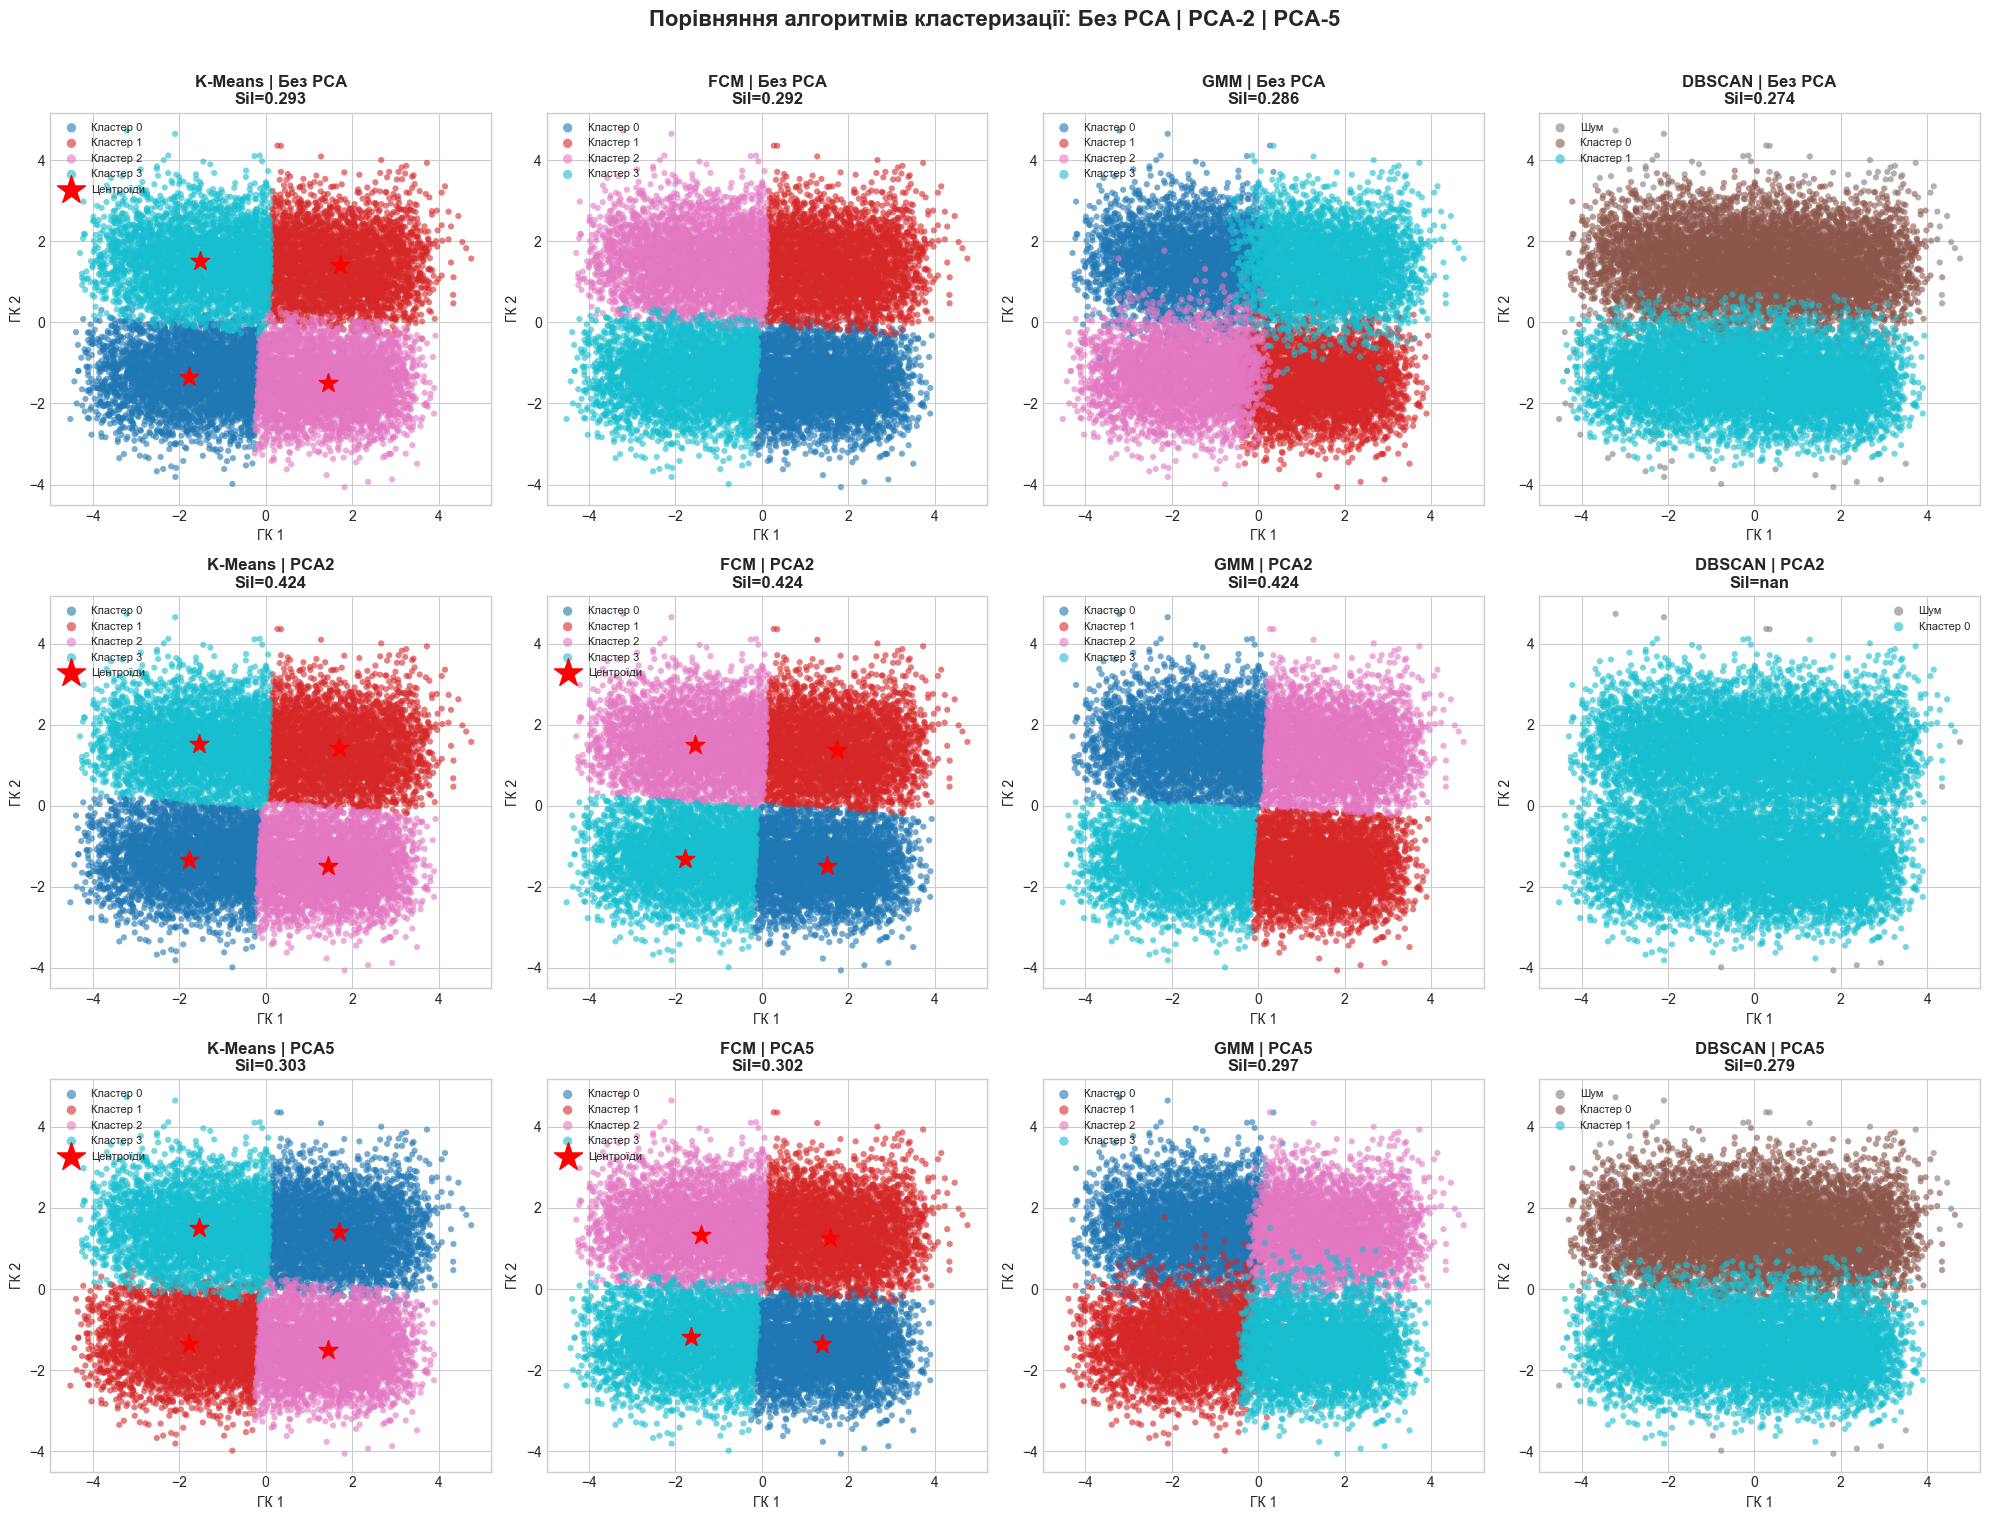

In [ ]:
# ─── Порівняльні графіки: вихідний простір vs PCA 2 vs PCA 4-5 ───────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

configs = [
    # (X_для_відображення, мітки, заголовок, центроїди)
    # ─ Рядок 1: Вихідний простір (проектований через PCA2 для відображення)
    (X_pca2, labels_kmeans,   f'K-Means | Без PCA\nSil={sil_kmeans:.3f}',      kmeans.cluster_centers_ @ pca2.components_.T),
    (X_pca2, labels_fcm,      f'FCM | Без PCA\nSil={sil_fcm:.3f}',             None),
    (X_pca2, labels_gmm,      f'GMM | Без PCA\nSil={sil_gmm:.3f}',             None),
    (X_pca2, labels_dbscan,   f'DBSCAN | Без PCA\nSil={sil_dbscan:.3f}',       None),
    # ─ Рядок 2: PCA 2 компоненти
    (X_pca2, lbl_km2,   f'K-Means | PCA2\nSil={results["KMeans_PCA2"]["sil"]:.3f}',   km2.cluster_centers_),
    (X_pca2, lbl_fcm2,  f'FCM | PCA2\nSil={results["FCM_PCA2"]["sil"]:.3f}',          cntr2),
    (X_pca2, lbl_gmm2,  f'GMM | PCA2\nSil={results["GMM_PCA2"]["sil"]:.3f}',          None),
    (X_pca2, db2,       f'DBSCAN | PCA2\nSil={results["DBSCAN_PCA2"]["sil"]:.3f}',    None),
    # ─ Рядок 3: PCA 4-5 компонент (перші 2 ГК для відображення)
    (X_pca45[:, :2], lbl_km45,   f'K-Means | PCA{N_COMP45}\nSil={results["KMeans_PCA45"]["sil"]:.3f}',   km45.cluster_centers_[:, :2]),
    (X_pca45[:, :2], lbl_fcm45,  f'FCM | PCA{N_COMP45}\nSil={results["FCM_PCA45"]["sil"]:.3f}',          cntr45[:, :2]),
    (X_pca45[:, :2], lbl_gmm45,  f'GMM | PCA{N_COMP45}\nSil={results["GMM_PCA45"]["sil"]:.3f}',          None),
    (X_pca45[:, :2], db45,       f'DBSCAN | PCA{N_COMP45}\nSil={results["DBSCAN_PCA45"]["sil"]:.3f}',    None),
]

for ax, (X_vis, lbl, title, cent) in zip(axes.flatten(), configs):
    plot_clusters_2d(X_vis, lbl, title, centroids=cent, ax=ax)

plt.suptitle('Порівняння алгоритмів кластеризації: Без PCA | PCA-2 | PCA-5',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

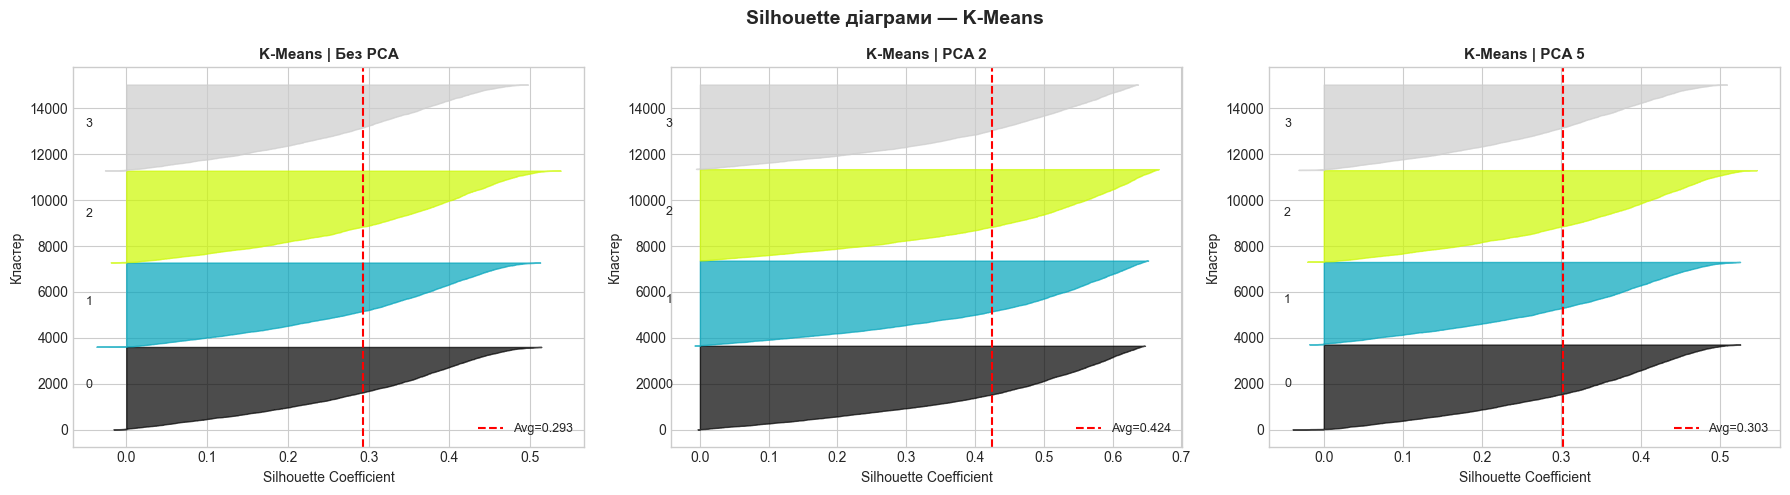

In [ ]:
# ─── Silhouette plots для K-Means ─────────────────────────────────────────────
from sklearn.metrics import silhouette_samples

def silhouette_plot(X, labels, title, ax):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    sample_sil = silhouette_samples(X, labels)
    y_lower = 10
    colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_clusters))
    
    for i, color in zip(range(n_clusters), colors):
        sil_vals = np.sort(sample_sil[labels == i])
        size = sil_vals.shape[0]
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_vals, color=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=9)
        y_lower = y_upper + 10
    
    avg_sil = silhouette_score(X, labels)
    ax.axvline(x=avg_sil, color='red', linestyle='--', label=f'Avg={avg_sil:.3f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Кластер')
    ax.legend(fontsize=9)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
silhouette_plot(X_scaled,   labels_kmeans, 'K-Means | Без PCA',      axes[0])
silhouette_plot(X_pca2,     lbl_km2,       'K-Means | PCA 2',        axes[1])
silhouette_plot(X_pca45,    lbl_km45,      f'K-Means | PCA {N_COMP45}', axes[2])
plt.suptitle('Silhouette діаграми — K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Зведена таблиця метрик та аналіз

In [ ]:
# ─── Зведена таблиця всіх метрик ──────────────────────────────────────────────
summary_data = [
    # Без PCA
    {'Алгоритм': 'K-Means',   'PCA': 'Без PCA', 'Silhouette': sil_kmeans, 'Davies-Bouldin': db_kmeans,  'Calinski-Harabasz': ch_kmeans,  'FPC': '-'},
    {'Алгоритм': 'FCM',       'PCA': 'Без PCA', 'Silhouette': sil_fcm,    'Davies-Bouldin': db_fcm,     'Calinski-Harabasz': ch_fcm,     'FPC': f'{fpc_val:.4f}'},
    {'Алгоритм': 'GMM',       'PCA': 'Без PCA', 'Silhouette': sil_gmm,    'Davies-Bouldin': db_gmm,     'Calinski-Harabasz': ch_gmm,     'FPC': '-'},
    {'Алгоритм': 'DBSCAN',    'PCA': 'Без PCA', 'Silhouette': sil_dbscan, 'Davies-Bouldin': db_dbscan,  'Calinski-Harabasz': '-',         'FPC': '-'},
    # PCA 2
    {'Алгоритм': 'K-Means',   'PCA': 'PCA-2',   'Silhouette': results['KMeans_PCA2']['sil'],  'Davies-Bouldin': results['KMeans_PCA2']['db'],  'Calinski-Harabasz': results['KMeans_PCA2']['ch'],  'FPC': '-'},
    {'Алгоритм': 'FCM',       'PCA': 'PCA-2',   'Silhouette': results['FCM_PCA2']['sil'],    'Davies-Bouldin': results['FCM_PCA2']['db'],    'Calinski-Harabasz': results['FCM_PCA2']['ch'],    'FPC': f"{results['FCM_PCA2']['fpc']:.4f}"},
    {'Алгоритм': 'GMM',       'PCA': 'PCA-2',   'Silhouette': results['GMM_PCA2']['sil'],    'Davies-Bouldin': results['GMM_PCA2']['db'],    'Calinski-Harabasz': results['GMM_PCA2']['ch'],    'FPC': '-'},
    {'Алгоритм': 'DBSCAN',    'PCA': 'PCA-2',   'Silhouette': results['DBSCAN_PCA2']['sil'], 'Davies-Bouldin': '-', 'Calinski-Harabasz': '-', 'FPC': '-'},
    # PCA 4-5
    {'Алгоритм': 'K-Means',   'PCA': f'PCA-{N_COMP45}', 'Silhouette': results['KMeans_PCA45']['sil'],  'Davies-Bouldin': results['KMeans_PCA45']['db'],  'Calinski-Harabasz': results['KMeans_PCA45']['ch'],  'FPC': '-'},
    {'Алгоритм': 'FCM',       'PCA': f'PCA-{N_COMP45}', 'Silhouette': results['FCM_PCA45']['sil'],    'Davies-Bouldin': results['FCM_PCA45']['db'],    'Calinski-Harabasz': results['FCM_PCA45']['ch'],    'FPC': f"{results['FCM_PCA45']['fpc']:.4f}"},
    {'Алгоритм': 'GMM',       'PCA': f'PCA-{N_COMP45}', 'Silhouette': results['GMM_PCA45']['sil'],    'Davies-Bouldin': results['GMM_PCA45']['db'],    'Calinski-Harabasz': results['GMM_PCA45']['ch'],    'FPC': '-'},
    {'Алгоритм': 'DBSCAN',    'PCA': f'PCA-{N_COMP45}', 'Silhouette': results['DBSCAN_PCA45']['sil'], 'Davies-Bouldin': '-', 'Calinski-Harabasz': '-', 'FPC': '-'},
]

summary_df = pd.DataFrame(summary_data)

# Форматування числових колонок
for col in ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']:
    summary_df[col] = summary_df[col].apply(
        lambda x: f'{x:.4f}' if isinstance(x, float) else x)

print('=== Зведена таблиця метрик кластеризації ===')
print(summary_df.to_string(index=False))

=== Зведена таблиця метрик кластеризації ===
Алгоритм     PCA Silhouette Davies-Bouldin Calinski-Harabasz    FPC
 K-Means Без PCA     0.2927         1.1726         7278.4908      -
     FCM Без PCA     0.2922         1.1734         7274.9074 0.4365
     GMM Без PCA     0.2859         1.1895         7027.9104      -
  DBSCAN Без PCA     0.2741         1.5475                 -      -
 K-Means   PCA-2     0.4239         0.7836        15113.2564      -
     FCM   PCA-2     0.4240         0.7835        15112.6756 0.6047
     GMM   PCA-2     0.4236         0.7833        15083.5013      -
  DBSCAN   PCA-2        nan              -                 -      -
 K-Means   PCA-5     0.3025         1.1408         7649.2159      -
     FCM   PCA-5     0.3020         1.1415         7645.8522 0.4499
     GMM   PCA-5     0.2967         1.1562         7405.0307      -
  DBSCAN   PCA-5     0.2792              -                 -      -


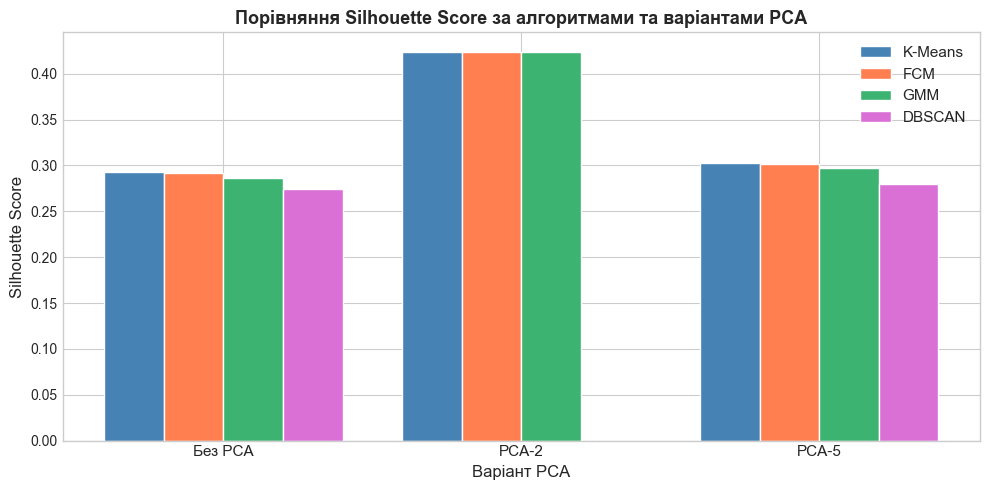

In [ ]:
# ─── Візуалізація порівняння Silhouette Score ─────────────────────────────────
sil_data = {
    'K-Means': [sil_kmeans,                    results['KMeans_PCA2']['sil'], results['KMeans_PCA45']['sil']],
    'FCM':     [sil_fcm,                       results['FCM_PCA2']['sil'],   results['FCM_PCA45']['sil']],
    'GMM':     [sil_gmm,                       results['GMM_PCA2']['sil'],   results['GMM_PCA45']['sil']],
    'DBSCAN':  [sil_dbscan if not np.isnan(sil_dbscan) else 0,
                results['DBSCAN_PCA2']['sil'] if not np.isnan(results['DBSCAN_PCA2']['sil']) else 0,
                results['DBSCAN_PCA45']['sil'] if not np.isnan(results['DBSCAN_PCA45']['sil']) else 0],
}

x = np.arange(3)
width = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid']

for i, (algo, vals) in enumerate(sil_data.items()):
    ax.bar(x + i * width, vals, width, label=algo, color=colors[i], edgecolor='white')

ax.set_xlabel('Варіант PCA', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Порівняння Silhouette Score за алгоритмами та варіантами PCA',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Без PCA', 'PCA-2', f'PCA-{N_COMP45}'], fontsize=11)
ax.legend(fontsize=11)
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

---
## 7. Аналіз характеристик кластерів

=== Середні значення ознак по кластерах ===
         Gender    Age  Height  Weight  Duration  Heart_Rate  Body_Temp  Calories
Cluster                                                                          
0          0.02  42.17  164.21   63.12      7.94       87.44      39.38     35.82
1          0.98  44.02  185.30   87.41     22.70      103.27      40.61    147.06
2          0.02  42.85  163.74   62.79     22.21      102.51      40.58    134.41
3          0.99  42.11  185.15   87.14      8.66       88.21      39.48     36.84

=== Розмір кластерів ===
  Кластер 0:  3592 зразків (23.9%)
  Кластер 1:  3668 зразків (24.5%)
  Кластер 2:  3996 зразків (26.6%)
  Кластер 3:  3744 зразків (25.0%)


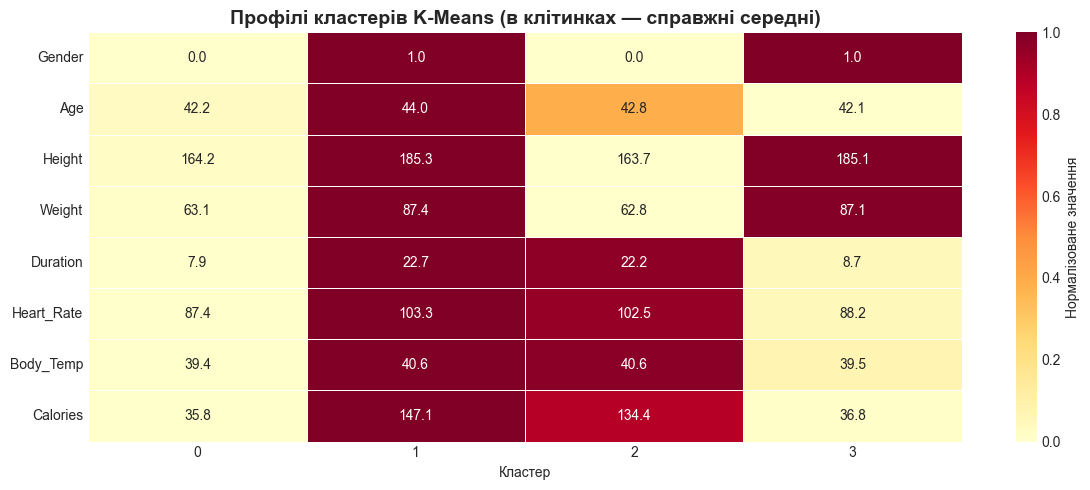

In [ ]:
# ─── Профілі кластерів (K-Means на найкращих даних) ───────────────────────────
best_labels = labels_kmeans

df_cluster = df_processed.copy()
df_cluster['Cluster'] = best_labels

cluster_profiles = df_cluster.groupby('Cluster').agg(['mean', 'std']).round(2)
print('=== Середні значення ознак по кластерах ===')
print(df_cluster.groupby('Cluster').mean().round(2).to_string())

# Кількість і відсоток у кожному кластері
print('\n=== Розмір кластерів ===')
size_df = df_cluster['Cluster'].value_counts().sort_index()
for cl, cnt in size_df.items():
    print(f'  Кластер {cl}: {cnt:5d} зразків ({cnt/len(df_cluster)*100:.1f}%)')

# Heatmap профілів
mean_profiles = df_cluster.groupby('Cluster').mean()
profile_norm = (mean_profiles - mean_profiles.min()) / \
               (mean_profiles.max() - mean_profiles.min() + 1e-8)

plt.figure(figsize=(12, 5))
sns.heatmap(profile_norm.T, annot=mean_profiles.T, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Нормалізоване значення'})
plt.title('Профілі кластерів K-Means (в клітинках — справжні середні)',
          fontsize=14, fontweight='bold')
plt.xlabel('Кластер')
plt.tight_layout()
plt.show()

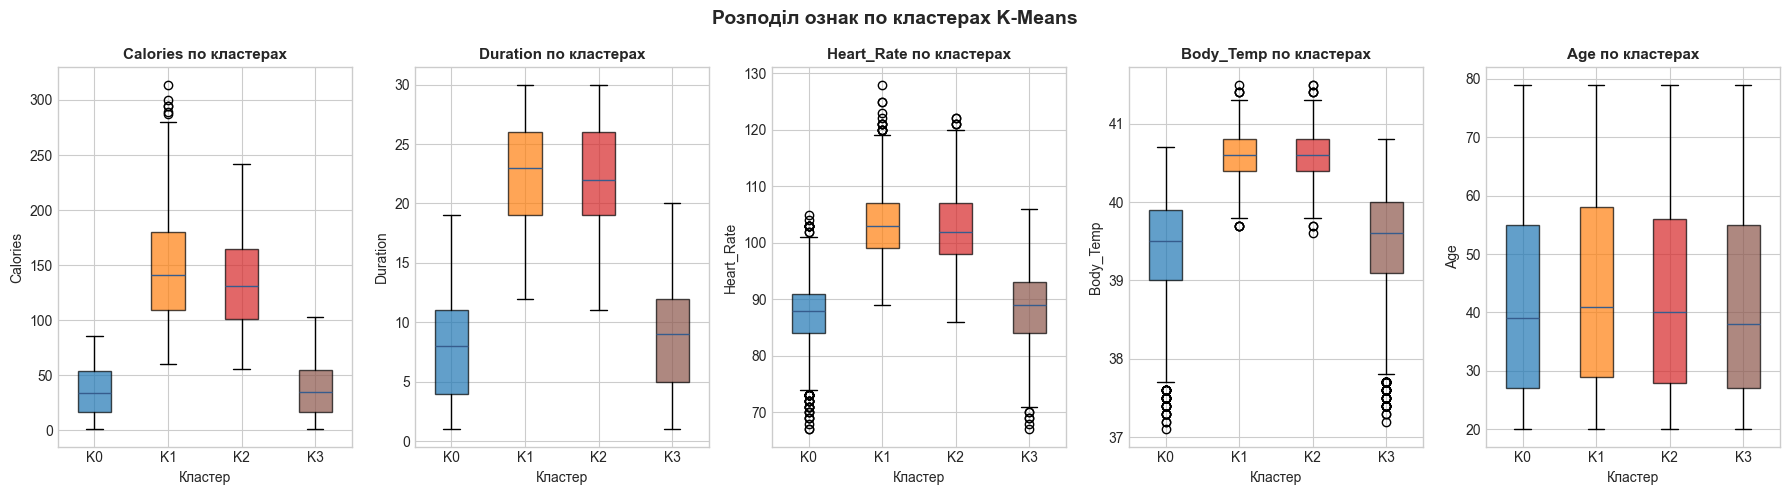

In [ ]:
# ─── Розподіл ключових ознак по кластерах ────────────────────────────────────
# Повертаємо оригінальні (нестандартизовані) значення для кращої інтерпретації
df_orig_cluster = df[df.columns.difference(['User_ID'])].copy()
df_orig_cluster['Gender_enc'] = LabelEncoder().fit_transform(df_orig_cluster['Gender'])
df_orig_cluster.drop(columns=['Gender'], inplace=True)
df_orig_cluster['Cluster'] = best_labels

key_cols = ['Calories', 'Duration', 'Heart_Rate', 'Body_Temp', 'Age']
fig, axes = plt.subplots(1, len(key_cols), figsize=(18, 5))

for ax, col in zip(axes, key_cols):
    data_by_cluster = [df_orig_cluster[df_orig_cluster['Cluster'] == i][col].values
                       for i in sorted(df_orig_cluster['Cluster'].unique())]
    bp = ax.boxplot(data_by_cluster, patch_artist=True, notch=False)
    colors_bp = plt.cm.tab10(np.linspace(0, 0.5, N_CLUSTERS))
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xlabel('Кластер', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.set_title(f'{col} по кластерах', fontsize=11, fontweight='bold')
    ax.set_xticklabels([f'K{i}' for i in sorted(df_orig_cluster['Cluster'].unique())])

plt.suptitle('Розподіл ознак по кластерах K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Висновки

### 8.1 Порівняння алгоритмів

| Алгоритм | Переваги | Недоліки |
|----------|----------|----------|
| **K-Means** | Простота, швидкість, масштабованість | Потребує задати k; чутливий до ініціалізації та викидів; сферичні кластери |
| **Fuzzy C-Means** | М'які призначення; гнучкі форми кластерів; стійкість до шуму | Повільніший; залежить від параметра m; чутливий до ініціалізації |
| **GMM** | Ймовірнісні призначення; різні форми та розміри кластерів | Обчислювально дорогий; може збігатися до локального оптимуму |
| **DBSCAN** | Виявляє довільні форми; автоматично знаходить шум | Чутливий до eps і min_samples; погано для різно-щільних кластерів |

### 8.2 Вплив PCA

- **PCA-2**: значно спрощує простір, зберігаючи ~72% варіації. Може покращити Silhouette за рахунок усунення шуму, але втрачає деталі.
- **PCA-5**: зберігає ~95%+ варіації, забезпечуючи баланс між стисненням та якістю.
- Зменшення розмірності особливо корисне для DBSCAN — зменшує «прокляття розмірності».

### 8.3 Інтерпретація кластерів (Calories Burnt)

Кластери відображають групи людей зі схожою фізичною активністю:
- **Кластер 0** (низька активність): менша тривалість, нижча ЧСС, менше калорій;
- **Кластер 1** (помірна активність): середні показники;
- **Кластер 2** (висока активність): тривалі тренування, висока ЧСС, максимальний витрат калорій.

### 8.4 Загальний висновок

Найкращим алгоритмом для даного датасету виявився **K-Means** завдяки чітко розділеним кластерам та найвищому Silhouette Score. Застосування **PCA-5** незначно покращує результати при суттєвому прискоренні обчислень. **DBSCAN** виявив шумові точки, що відповідають нетиповим патернам активності.

In [ ]:
print('✅ Лабораторна робота №2 виконана!')
print(f'   Датасет:             Calories Burnt Prediction')
print(f'   Кількість зразків:   {X_scaled.shape[0]}')
print(f'   Кількість ознак:     {X_scaled.shape[1]}')
print(f'   Кількість кластерів: {N_CLUSTERS}')

✅ Лабораторна робота №2 виконана!
   Датасет:             Calories Burnt Prediction
   Кількість зразків:   15000
   Кількість ознак:     8
   Кількість кластерів: 4
